# Main paper — comparison figures

In [4]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [5]:
plt.style.use(str(Path("..") / "plot_style.mplstyle"))

In [11]:
# ---- Constants -------------------------------------------------------------

BASE = Path("..") / "comparison" / "results"
assert BASE.exists(), BASE

MOLECULE_DATASETS = ["cyp2c19_veith", "caco2_wang", "pgp_broccatelli", "ames", "lipophilicity", "sr_are"]
DNA_DATASETS = ["gue_prom_core_all", "gue_prom_300_all", "gue_emp_h3", "gue_emp_h4", "gue_mouse_0", "deeppromoter"]
PROTEIN_DATASETS = ["dbaasp_amp"]

# mmseqs2 only applies to the protein dataset (dbaasp_amp) -- excluded from the
# default method list so it doesn't eat a color slot / legend entry on
# molecule and DNA plots. Pass methods=ALL_METHODS explicitly to include it.
METHODS = ["refnd", "hestia", "datasail", "random"]
ALL_METHODS = ["refnd", "hestia", "mmseqs2", "datasail", "random"]

# Colors are assigned by position within whichever method list is in use, so
# they always come from the theme's axes.prop_cycle (plot_style.mplstyle) --
# never hardcoded.
_cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def method_colors(methods: list[str]) -> dict[str, str]:
    return {method: _cycle_colors[i % len(_cycle_colors)] for i, method in enumerate(methods)}

METHOD_COLOR = method_colors(METHODS)

In [8]:
# ---- Data loading helper ----------------------------------------------------

def load_summary(modality: str, dataset: str) -> dict:
    with open(BASE / modality / dataset / "summary.json") as f:
        return json.load(f)

def get_test_values(modality: str, dataset: str, method: str, head: str = "mlp") -> np.ndarray | None:
    """10-seed raw test scores for one dataset/method/head, or None if the method wasn't run on this dataset."""
    d = load_summary(modality, dataset)
    if method not in d:
        return None
    return np.array(d[method][head]["test"]["values"])

print("loader ready")

loader ready


/tmp/ipykernel_1184550/412774082.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


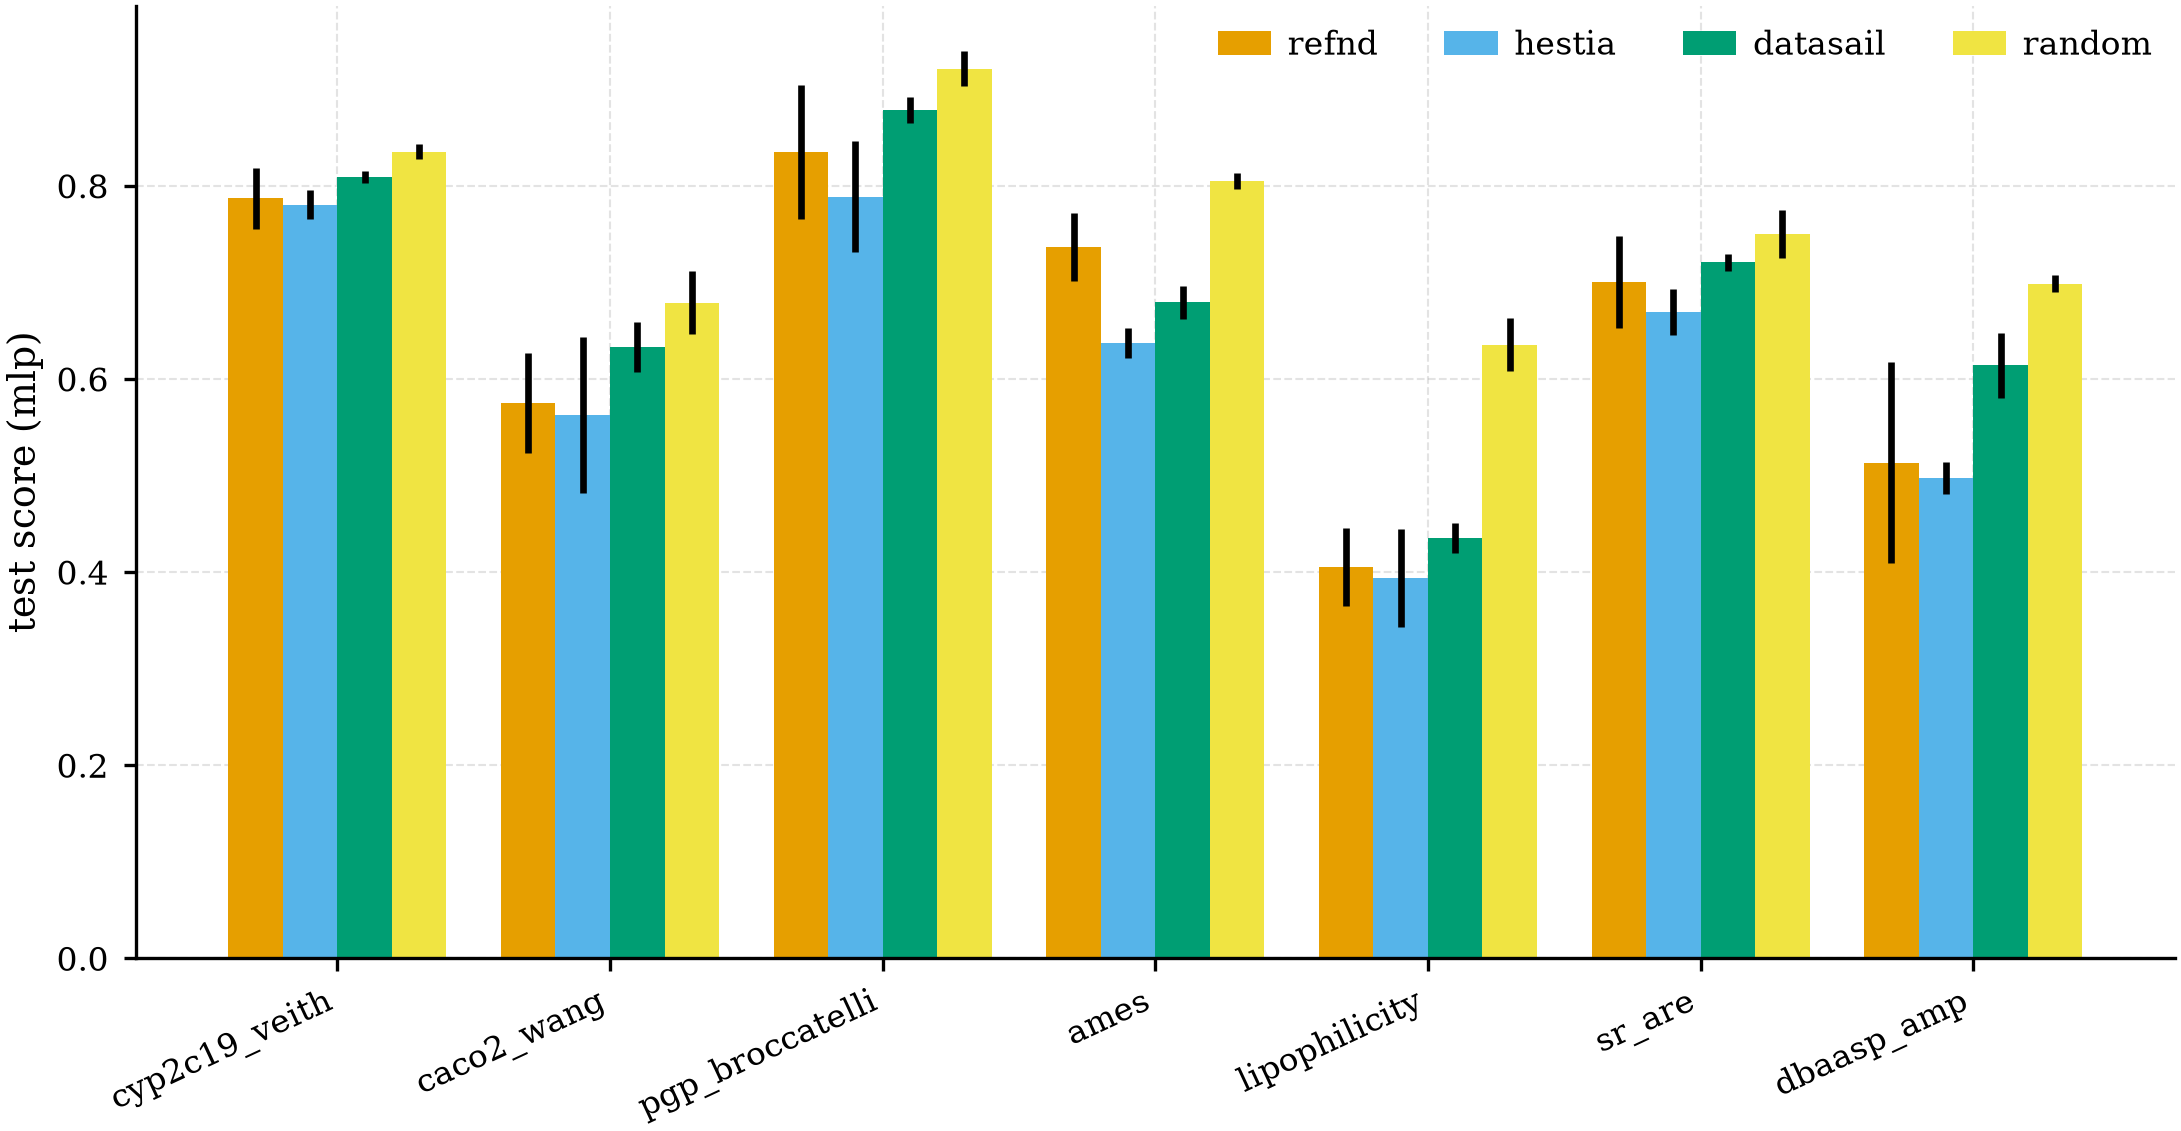

In [22]:
def plot_bar_combined(groups: list[tuple[str, str]], head: str = "mlp", methods: list[str] = METHODS):
    """groups: list of (modality, dataset) pairs, plotted left to right."""
    n_methods = len(methods)
    colors = method_colors(methods)
    x = np.arange(len(groups))
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(7.5, 4))
    for i, method in enumerate(methods):
        means, stds = [], []
        for modality, ds in groups:
            vals = get_test_values(modality, ds, method, head)
            means.append(np.nan if vals is None else vals.mean())
            stds.append(np.nan if vals is None else vals.std())
        offset = (i - (n_methods - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, label=method, color=colors[method])

    ax.set_xticks(x)
    ax.set_xticklabels([ds for _, ds in groups], rotation=25, ha="right")
    ax.set_ylabel(f"test score ({head})")
    ax.legend(ncol=n_methods)
    fig.tight_layout()
    return fig, ax

groups = [("molecule", ds) for ds in MOLECULE_DATASETS] + [("protein", ds) for ds in PROTEIN_DATASETS]
plot_bar_combined(groups)
plt.show()

/tmp/ipykernel_1184550/412774082.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


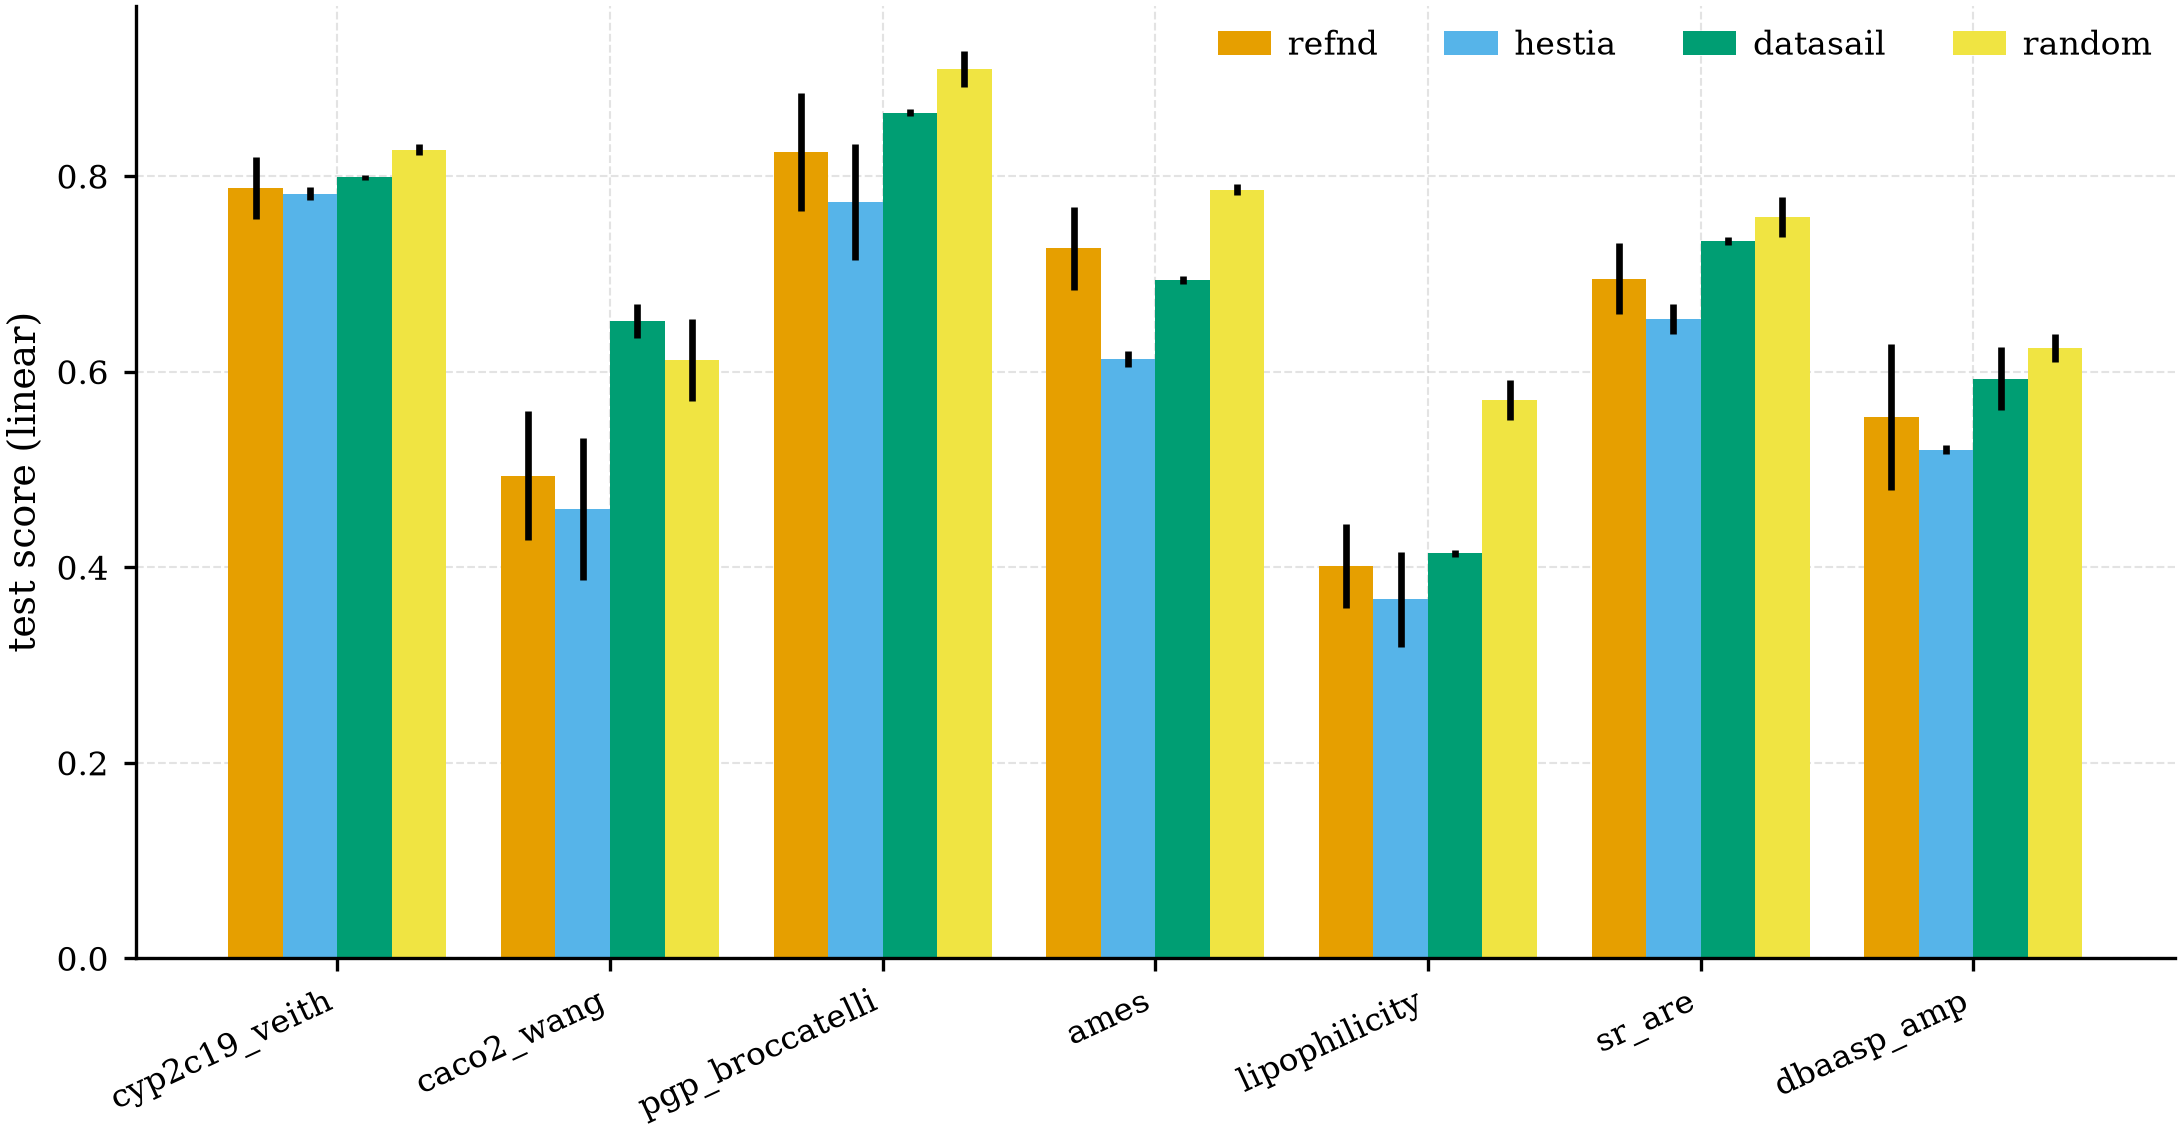

In [23]:
# ---- Same figure, Linear head -----------------------------------------------

plot_bar_combined(groups, head="linear")
plt.show()

In [24]:
# ---- Leakage / min-distance-to-train data loading ---------------------------
# comparison/results/leakage/{modality}/{dataset}/{method}_seed1.npy holds, per
# test sample, its max identity to the nearest train sample (Tanimoto for
# molecules, sequence identity for protein/DNA) -- i.e. 1 - min_distance.
# Single seed by design (see comparison/README.md).

LEAK_DIR = BASE / "leakage"
LEAK_THRESHOLD = {"molecule": 0.40, "dna": 0.40, "protein": 0.50}

def load_leakage(modality: str, dataset: str, method: str) -> np.ndarray | None:
    path = LEAK_DIR / modality / dataset / f"{method}_seed1.npy"
    if not path.exists():
        return None
    return np.load(path)

print("leakage loader ready")

leakage loader ready


/tmp/ipykernel_1184550/3132469235.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


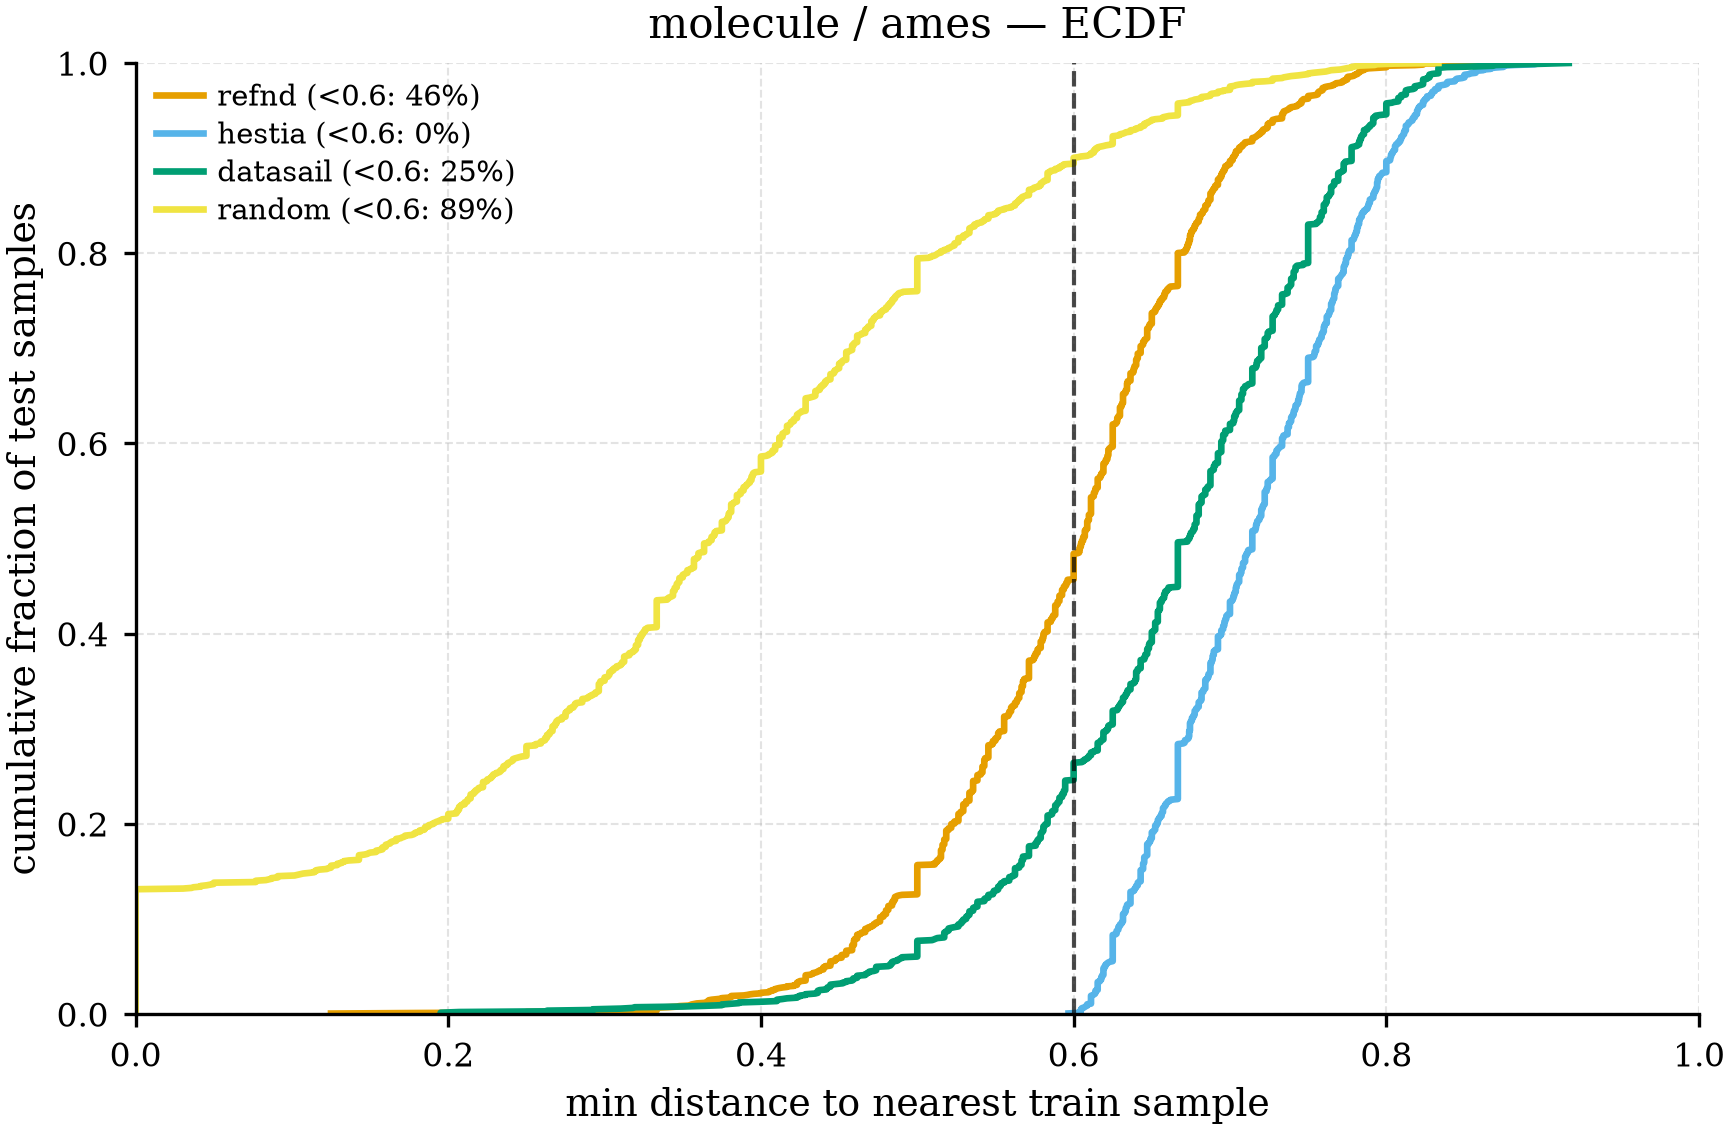

In [27]:
# ---- Draft A: ECDF of min distance to train, with threshold read-off --------

def plot_leakage_ecdf(modality: str, dataset: str, methods: list[str] = METHODS):
    dist_threshold = 1.0 - LEAK_THRESHOLD[modality]
    colors = method_colors(methods)

    fig, ax = plt.subplots(figsize=(6, 4))
    for method in methods:
        identity = load_leakage(modality, dataset, method)
        if identity is None:
            continue
        dist = 1.0 - identity
        x = np.sort(dist)
        y = np.arange(1, len(x) + 1) / len(x)
        frac_below = float((dist < dist_threshold).mean())
        ax.plot(x, y, color=colors[method], label=f"{method} (<{dist_threshold:g}: {frac_below:.0%})")

    ax.axvline(dist_threshold, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("min distance to nearest train sample")
    ax.set_ylabel("cumulative fraction of test samples")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{modality} / {dataset} — ECDF")
    ax.legend(fontsize=7)
    fig.tight_layout()
    return fig, ax

plot_leakage_ecdf("molecule", "ames")
plt.show()

/tmp/ipykernel_1184550/1018227511.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


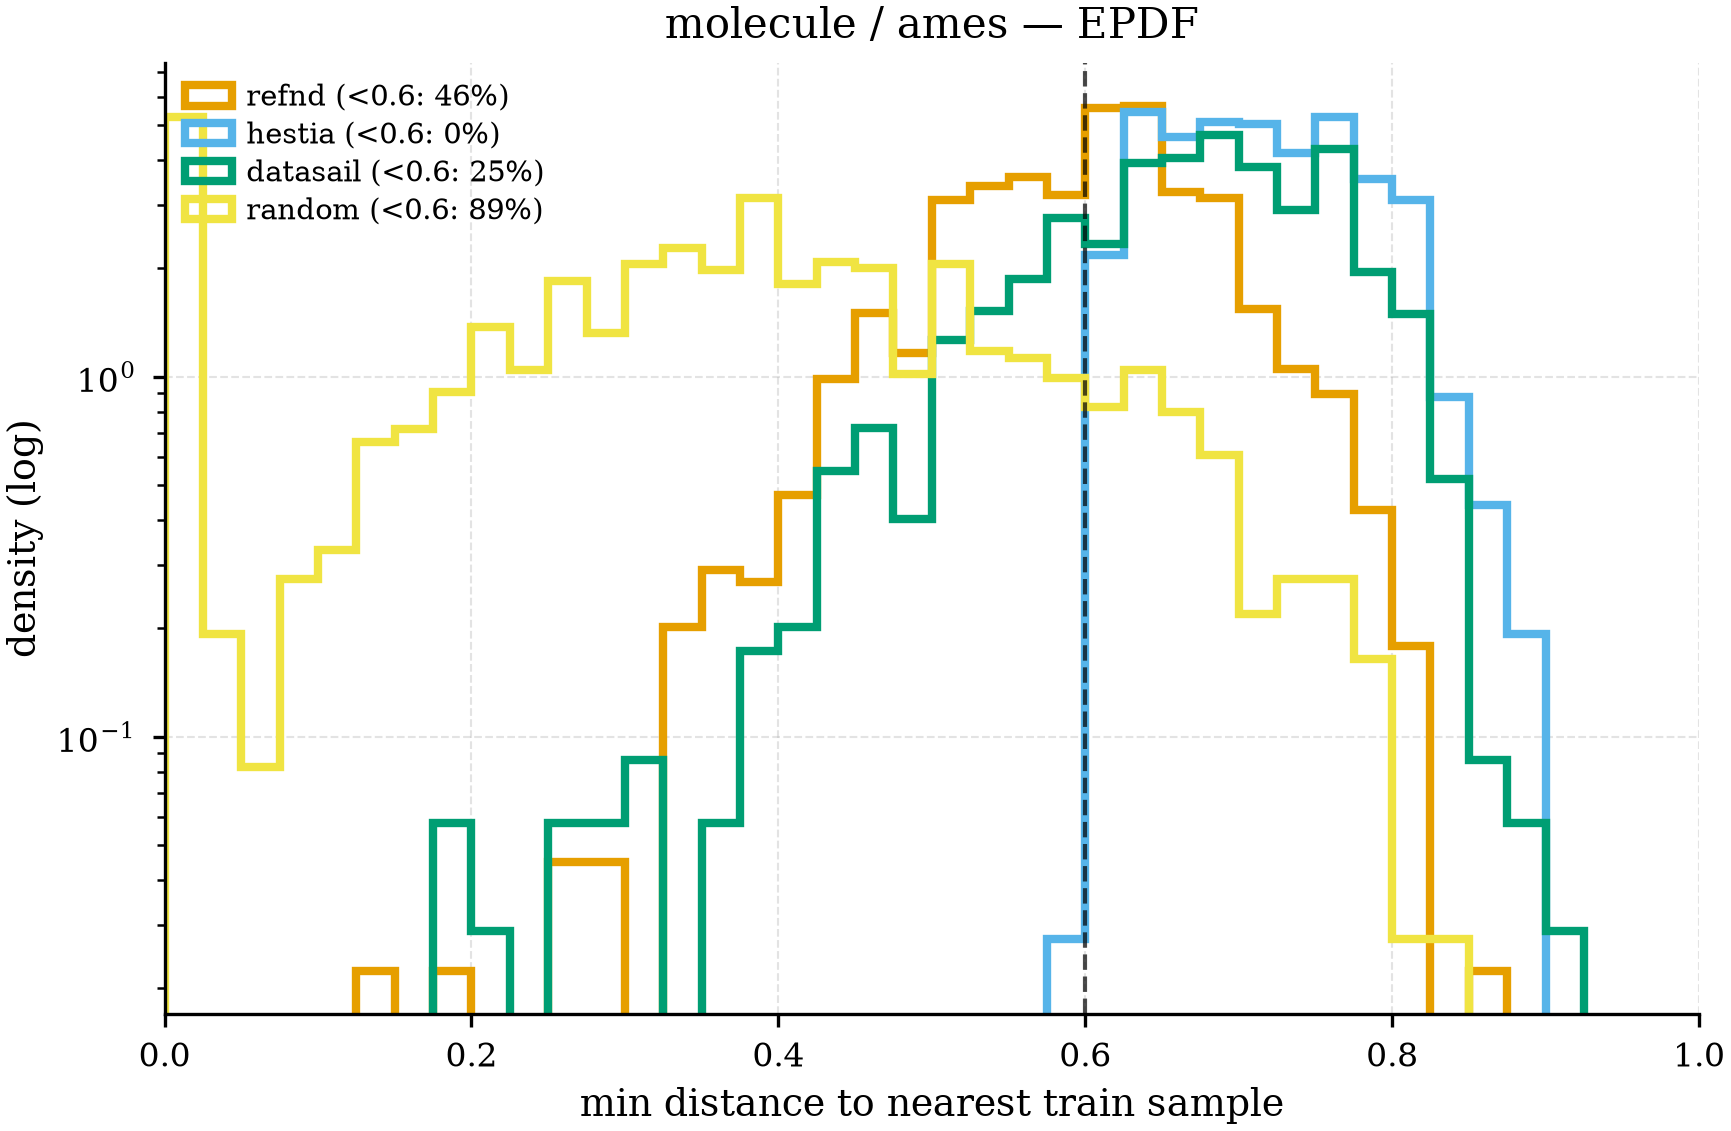

In [28]:
# ---- Draft B: EPDF (density histogram, log y) of min distance to train ------

def plot_leakage_epdf(modality: str, dataset: str, methods: list[str] = METHODS, logy: bool = True):
    dist_threshold = 1.0 - LEAK_THRESHOLD[modality]
    colors = method_colors(methods)
    bins = np.linspace(0, 1, 41)

    fig, ax = plt.subplots(figsize=(6, 4))
    for method in methods:
        identity = load_leakage(modality, dataset, method)
        if identity is None:
            continue
        dist = 1.0 - identity
        frac_below = float((dist < dist_threshold).mean())
        ax.hist(dist, bins=bins, density=True, histtype="step", linewidth=2,
                color=colors[method], label=f"{method} (<{dist_threshold:g}: {frac_below:.0%})")

    ax.axvline(dist_threshold, color="black", linestyle="--", linewidth=1, alpha=0.7)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("min distance to nearest train sample")
    ax.set_ylabel("density" + (" (log)" if logy else ""))
    ax.set_xlim(0, 1)
    ax.set_title(f"{modality} / {dataset} — EPDF")
    ax.legend(fontsize=7)
    fig.tight_layout()
    return fig, ax

plot_leakage_epdf("molecule", "ames")
plt.show()